<a href="https://colab.research.google.com/github/VasilisPapageorgiou/Cameroon/blob/main/RealCameroonExpSupplementary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
R = resume | S = start from beginning: S
Upload Cameroonmpox.csv


Saving Cameroonmpox.csv to Cameroonmpox.csv
checkpoint: weekly

Weekly observations = 24
Observed cases = 49
Fixed model = {'N': 175, 'S0': 114, 'I0': 1, 'b': 0.765, 'gamma': 0.2377, 'phi': 2.4906}

=== MAIN RESULTS ===
            Method  reporting     followup  ascertainment  Cost  TraceCov  Decision_U
 Decision-targeted   4.000000 3.053113e-16       0.000000   4.0  0.022883    0.266593
      Equal-budget   1.333333 8.888889e-01       0.666667   4.0  0.006321    0.490151
Parameter-oriented   0.817368 0.000000e+00       1.591316   4.0  0.005383    0.662781

=== SURVEILLANCE VALUE ===
       Source  MaxDecisionValuePerCost  MeanDecisionValuePerCost
    reporting                 0.002491                  0.000298
     followup                 0.002366                  0.000236
ascertainment                 0.001498                  0.000166

=== GEOMETRY ===
Leading variance share = 0.8896
Risk-direction alignment = 0.139
Corr(log b,log gamma) = 0.767


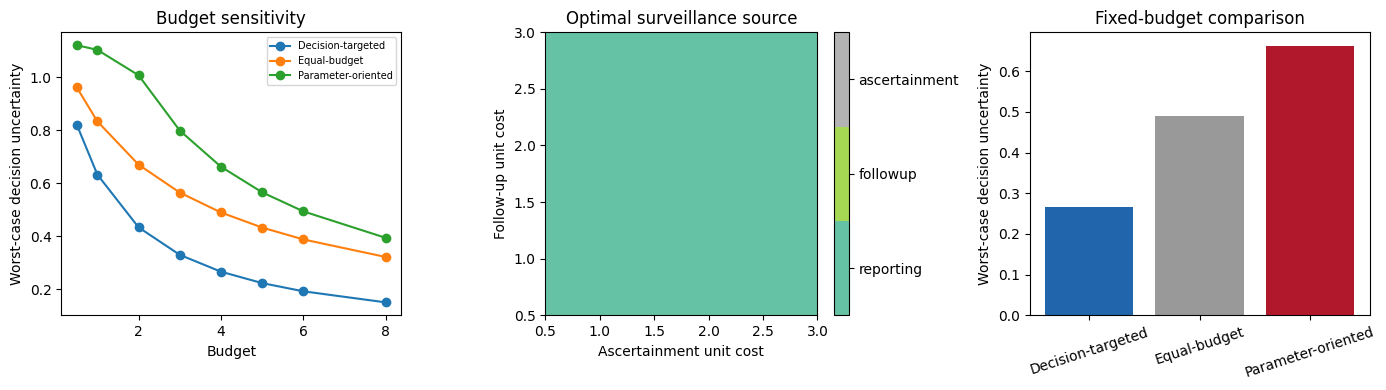


=== PAPER NUMBERS ===
Improvement vs equal allocation = 45.6%
Improvement vs parameter allocation = 59.8%

Cost-robust dominant source frequency
DominantSource
reporting    100.0%
Name: proportion, dtype: object

Gain robustness
 ReportingGain  FollowupGain  AscertainmentGain  Decision_U DominantSource
          0.75          0.75               0.75    0.330257      reporting
          1.00          1.00               1.00    0.266593      reporting
          1.25          1.00               1.00    0.223552      reporting
          1.00          1.25               1.00    0.266593      reporting
          1.00          1.00               1.25    0.266593      reporting
          0.75          1.25               1.00    0.330257      reporting
          1.25          0.75               1.00    0.223552      reporting
          1.00          1.25               0.75    0.266593      reporting
          1.00          0.75               1.25    0.266593      reporting
checkpoint: done

DO

In [1]:
# ============================================================
# CAMEROON MPOX — DECISION-TARGETED SURVEILLANCE ALLOCATION
# Full Colab pipeline using FIXED estimates from the main paper
# Weekly data | budget + cost + gain robustness
# Checkpoint every 20 min | only prompt = Resume or Start
# ============================================================

import os,time,pickle,json,warnings
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from scipy.optimize import minimize
warnings.filterwarnings("ignore")

from google.colab import drive,files
drive.mount("/content/drive")

# ============================================================
# SETTINGS
# ============================================================

ROOT="/content/drive/MyDrive/Cameroon_Surveillance_Allocation"
OUT=f"{ROOT}/results"; ROB=f"{OUT}/robustness"; CKPT=f"{ROOT}/checkpoint.pkl"
os.makedirs(OUT,exist_ok=True); os.makedirs(ROB,exist_ok=True)

# --- FIXED VALUES FROM MAIN PAPER ---
N=175
S0=114
I0=1
R0=60

BETA=0.7650
GAMMA=0.2377
PHI=2.4906

ETA=np.log([BETA,GAMMA])

SIGMA=np.array([
    [0.0108,0.0103],
    [0.0103,0.0167]
])

THRESH=np.array([57,68,80,91,103])

# normalized resource assumptions
COST={"reporting":1.0,"followup":1.5,"ascertainment":2.0}
BUDGET=4.0

# calibrated surveillance gain assumptions
REPORTING_GAIN=2.0
FOLLOWUP_GAIN=1.0
ASCERTAINMENT_GAIN=1.25

# robustness grids
BUDGETS=np.array([.5,1,2,3,4,5,6,8])
COST_GRID=np.linspace(.5,3,11)

# ============================================================
# RESUME / START
# ============================================================

ans=input("R = resume | S = start from beginning: ").strip().lower()
resume=ans.startswith("r") and os.path.exists(CKPT)

if not resume and os.path.exists(CKPT):
    os.remove(CKPT)

state=pickle.load(open(CKPT,"rb")) if resume else {}
last_save=time.time()

def save(stage,force=False,**kw):
    global state,last_save
    state.update(kw); state["stage"]=stage
    if force or time.time()-last_save>=1200:
        with open(CKPT,"wb") as f: pickle.dump(state,f)
        last_save=time.time()
        print("checkpoint:",stage)

# ============================================================
# 1. WEEKLY DATA
# ============================================================

if "weekly" not in state:

    paths=[
        "/content/Cameroonmpox.csv",
        f"{ROOT}/Cameroonmpox.csv",
        "/content/drive/MyDrive/Cameroonmpox.csv"
    ]

    fn=next((p for p in paths if os.path.exists(p)),None)

    if fn is None:
        print("Upload Cameroonmpox.csv")
        up=files.upload()
        fn="/content/"+next(iter(up))

    df=pd.read_csv(fn)

    dcol=next(
        (c for c in df.columns if c.lower()=="date"),
        next(c for c in df.columns if "date" in c.lower())
    )

    df[dcol]=pd.to_datetime(df[dcol],errors="coerce")
    df=df.dropna(subset=[dcol]).sort_values(dcol).set_index(dcol)

    if "new_cases" in df.columns:
        z=pd.to_numeric(df["new_cases"],errors="coerce").fillna(0).clip(lower=0)
        weekly=z.resample("W-SUN").sum()
    else:
        cc=next(c for c in df.columns if "total_cases" in c.lower())
        z=pd.to_numeric(df[cc],errors="coerce").ffill()
        wc=z.resample("W-SUN").max().ffill()
        weekly=wc.diff().fillna(wc.iloc[0]).clip(lower=0)

    nz=np.flatnonzero(weekly.values>0)
    if len(nz):
        weekly=weekly.iloc[max(0,nz[0]-1):nz[-1]+1]

    save("weekly",True,weekly=weekly)

else:
    weekly=state["weekly"]

y=weekly.values.astype(float)
T=len(y)

print("\nWeekly observations =",T)
print("Observed cases =",int(y.sum()))
print("Fixed model =",{"N":N,"S0":S0,"I0":I0,"b":BETA,"gamma":GAMMA,"phi":PHI})

weekly.to_csv(f"{OUT}/weekly_cases.csv")

# ============================================================
# 2. EXACT FINAL-SIZE DISTRIBUTION
# ============================================================

def final_pmf(b,g,S=S0,I=I0,N=N):
    X={}

    for s in range(S+1):
        for i in range(N-s+1):

            if i==0 or s==0:
                z=np.zeros(s+1); z[0]=1.
                X[s,i]=z
                continue

            pinf=(b*s/N)/(b*s/N+g)

            rec=np.pad(
                X[s,i-1],
                (0,s+1-len(X[s,i-1]))
            )

            nxt=X[s-1,i+1]
            inf=np.zeros(s+1)
            inf[1:1+len(nxt)]=nxt

            X[s,i]=(1-pinf)*rec+pinf*inf

    return X[S,I]

# ============================================================
# 3. INTERVENTIONS FROM MAIN PAPER
# ============================================================

POL={
    "Recovery":(0.000,0.040),
    "Contact":(0.100,0.000),
    "BalancedA":(0.050,0.020),
    "BalancedB":(0.070,0.012),
    "Weak":(0.045,0.005),
    "VeryWeak":(0.025,0.004),
    "Minimal":(0.010,0.002)
}

REF="Recovery"
ALT=[a for a in POL if a!=REF]

def risk(eta,a):
    b,g=np.exp(eta)
    db,dg=POL[a]

    p=final_pmf(
        max(b-db,1e-8),
        g+dg
    )

    return np.array([
        p[c+1:].sum()
        if c<len(p)-1 else 0.
        for c in THRESH
    ])

def decision(eta):
    r0=risk(eta,REF)
    return np.concatenate([
        risk(eta,a)-r0
        for a in ALT
    ])

def jac(fun,x,e=1e-4):
    f=fun(x)
    J=np.zeros((len(f),len(x)))

    for j in range(len(x)):
        d=np.eye(len(x))[j]*e
        J[:,j]=(fun(x+d)-fun(x-d))/(2*e)

    return J

G=jac(decision,ETA)

# protects against tiny denominator from near-zero contrasts
nu=np.maximum(np.abs(decision(ETA)),.02)**2

# baseline information from covariance in main paper
IBASE=np.linalg.inv(SIGMA)

# ============================================================
# 4. SURVEILLANCE INFORMATION SOURCES
#
# Constructed relative to the fixed covariance geometry.
# Each source targets a different parameter direction.
# ============================================================

def unit(v):
    v=np.asarray(v,float)
    return v/np.linalg.norm(v)

# parameter directions
d_ratio=unit([1,-1])   # risk-relevant b/gamma contrast
d_common=unit([1,1])   # common rate direction
d_gamma=unit([0,1])    # removal / follow-up information

# reporting assumed to improve incidence information,
# therefore relatively strong in the risk-relevant direction
I_report=REPORTING_GAIN*np.outer(d_ratio,d_ratio)

# longer follow-up informs removal/recovery most strongly
I_follow=FOLLOWUP_GAIN*np.outer(d_gamma,d_gamma)

# ascertainment mainly informs transmission/common incidence scale
I_asc=ASCERTAINMENT_GAIN*np.outer(d_common,d_common)

Ij={
    "reporting":I_report,
    "followup":I_follow,
    "ascertainment":I_asc
}

src=list(Ij)
c0=np.array([COST[s] for s in src])

# scale source information relative to baseline information magnitude
scale=np.trace(IBASE)/3
Ij={s:scale*Ij[s] for s in src}

# ============================================================
# 5. ALLOCATION OBJECTIVES
# ============================================================

def Sigma_w(w,IJ=Ij):
    I=IBASE.copy()

    for j,s in enumerate(src):
        I+=w[j]*IJ[s]

    return np.linalg.inv(I)

def decision_U(w,IJ=Ij):
    S=Sigma_w(w,IJ)
    v=np.einsum("ij,jk,ik->i",G,S,G)
    return np.max(v/nu)

def solve(B,c,IJ=Ij,mode="decision"):

    w0=B/(len(c)*c)

    con={"type":"ineq","fun":lambda w:B-c@w}
    bounds=[(0,B/x) for x in c]

    fun=(lambda w:decision_U(w,IJ)) if mode=="decision" \
        else (lambda w:np.trace(Sigma_w(w,IJ)))

    sol=minimize(
        fun,w0,
        method="SLSQP",
        bounds=bounds,
        constraints=con,
        options={"maxiter":1000,"ftol":1e-12}
    )

    w=sol.x
    return w,decision_U(w,IJ),np.trace(Sigma_w(w,IJ))

# ============================================================
# 6. MAIN ALLOCATION
# ============================================================

wd,Ud,Td=solve(BUDGET,c0,mode="decision")
wp,Up,Tp=solve(BUDGET,c0,mode="parameter")
we=BUDGET/(len(c0)*c0)

Ue=decision_U(we)
Te=np.trace(Sigma_w(we))

MAIN=pd.DataFrame([
    ["Decision-targeted",*wd,c0@wd,Td,Ud],
    ["Equal-budget",*we,c0@we,Te,Ue],
    ["Parameter-oriented",*wp,c0@wp,Tp,Up]
],columns=[
    "Method",*src,"Cost","TraceCov","Decision_U"
])

print("\n=== MAIN RESULTS ===")
print(MAIN.to_string(index=False))

MAIN.to_csv(f"{OUT}/main_allocation.csv",index=False)

# ============================================================
# 7. MARGINAL VALUE PER UNIT COST
# ============================================================

VAL=[]

for j,s in enumerate(src):

    gains=np.array([
        g@SIGMA@Ij[s]@SIGMA@g
        for g in G
    ])

    VAL.append([
        s,
        gains.max()/c0[j],
        gains.mean()/c0[j]
    ])

VAL=pd.DataFrame(
    VAL,
    columns=[
        "Source",
        "MaxDecisionValuePerCost",
        "MeanDecisionValuePerCost"
    ]
)

print("\n=== SURVEILLANCE VALUE ===")
print(VAL.to_string(index=False))
VAL.to_csv(f"{OUT}/source_value.csv",index=False)

# ============================================================
# 8. BUDGET ROBUSTNESS
# ============================================================

BR=[]

for B in BUDGETS:

    wd,Ud,Td=solve(B,c0,mode="decision")
    wp,Up,Tp=solve(B,c0,mode="parameter")
    we=B/(len(c0)*c0)

    for name,w,Uv,Tr in [
        ("Decision-targeted",wd,Ud,Td),
        ("Equal-budget",we,decision_U(we),np.trace(Sigma_w(we))),
        ("Parameter-oriented",wp,Up,Tp)
    ]:

        BR.append([
            B,name,Uv,Tr,*w
        ])

BR=pd.DataFrame(
    BR,
    columns=["Budget","Method","Decision_U","TraceCov",*src]
)

BR.to_csv(f"{ROB}/budget_sensitivity.csv",index=False)

# ============================================================
# 9. COST ROBUSTNESS
# ============================================================

CR=[]
WIN=np.zeros((len(COST_GRID),len(COST_GRID)),int)

for i,cf in enumerate(COST_GRID):

    for j,ca in enumerate(COST_GRID):

        cc=np.array([1.,cf,ca])

        w,Uv,Tr=solve(BUDGET,cc)

        winner=int(np.argmax(w))
        WIN[i,j]=winner

        CR.append([
            cf,ca,Uv,Tr,*w,src[winner]
        ])

CR=pd.DataFrame(
    CR,
    columns=[
        "FollowupCost",
        "AscertainmentCost",
        "Decision_U",
        "TraceCov",
        *src,
        "DominantSource"
    ]
)

CR.to_csv(f"{ROB}/cost_robustness.csv",index=False)

# ============================================================
# 10. INFORMATION-GAIN ROBUSTNESS
# ============================================================

gain_sets=[
    (.75,.75,.75),
    (1.,1.,1.),
    (1.25,1.,1.),
    (1.,1.25,1.),
    (1.,1.,1.25),
    (.75,1.25,1.),
    (1.25,.75,1.),
    (1.,1.25,.75),
    (1.,.75,1.25)
]

GR=[]

for a,b,d in gain_sets:

    mult=dict(zip(src,[a,b,d]))
    IJ={s:mult[s]*Ij[s] for s in src}

    w,Uv,Tr=solve(BUDGET,c0,IJ)

    GR.append([
        a,b,d,Uv,Tr,*w,src[np.argmax(w)]
    ])

GR=pd.DataFrame(
    GR,
    columns=[
        "ReportingGain",
        "FollowupGain",
        "AscertainmentGain",
        "Decision_U",
        "TraceCov",
        *src,
        "DominantSource"
    ]
)

GR.to_csv(f"{ROB}/gain_robustness.csv",index=False)

# ============================================================
# 11. GEOMETRY CHECK FROM MAIN PAPER
# ============================================================

lam,V=np.linalg.eigh(SIGMA)
o=np.argsort(lam)[::-1]
lam,V=lam[o],V[:,o]

riskdir=unit([1,-1])
alignment=abs(V[:,0]@riskdir)

print("\n=== GEOMETRY ===")
print("Leading variance share =",round(lam[0]/lam.sum(),4))
print("Risk-direction alignment =",round(alignment,4))
print("Corr(log b,log gamma) =",
      round(SIGMA[0,1]/np.sqrt(SIGMA[0,0]*SIGMA[1,1]),4))

# ============================================================
# 12. FIGURES
# ============================================================

fig,ax=plt.subplots(1,3,figsize=(14,4))

# Budget
for m,g in BR.groupby("Method"):
    ax[0].plot(g.Budget,g.Decision_U,"o-",label=m)

ax[0].set_xlabel("Budget")
ax[0].set_ylabel("Worst-case decision uncertainty")
ax[0].set_title("Budget sensitivity")
ax[0].legend(fontsize=7)

# Cost heatmap
im=ax[1].imshow(
    WIN,
    origin="lower",
    aspect="auto",
    extent=[
        COST_GRID.min(),COST_GRID.max(),
        COST_GRID.min(),COST_GRID.max()
    ],
    cmap=plt.cm.get_cmap("Set2",len(src)),
    vmin=-.5,vmax=len(src)-.5
)

ax[1].set_xlabel("Ascertainment unit cost")
ax[1].set_ylabel("Follow-up unit cost")
ax[1].set_title("Optimal surveillance source")

cb=plt.colorbar(im,ax=ax[1],ticks=range(len(src)))
cb.ax.set_yticklabels(src)

# Fixed budget
z=MAIN.set_index("Method")

ax[2].bar(
    z.index,
    z.Decision_U,
    color=["#2166ac","#999999","#b2182b"]
)

ax[2].set_ylabel("Worst-case decision uncertainty")
ax[2].set_title("Fixed-budget comparison")
ax[2].tick_params(axis="x",rotation=18)

plt.tight_layout()
plt.savefig(
    f"{OUT}/surveillance_allocation_summary.png",
    dpi=300,bbox_inches="tight"
)
plt.show()

# ============================================================
# 13. KEY NUMBERS
# ============================================================

M=MAIN.set_index("Method")

uD=M.loc["Decision-targeted","Decision_U"]
uE=M.loc["Equal-budget","Decision_U"]
uP=M.loc["Parameter-oriented","Decision_U"]

print("\n=== PAPER NUMBERS ===")
print(
    "Improvement vs equal allocation =",
    f"{100*(uE-uD)/uE:.1f}%"
)

print(
    "Improvement vs parameter allocation =",
    f"{100*(uP-uD)/uP:.1f}%"
)

print("\nCost-robust dominant source frequency")
print(
    CR.DominantSource.value_counts(normalize=True)
    .mul(100).round(1).astype(str)+"%"
)

print("\nGain robustness")
print(
    GR[
        [
            "ReportingGain",
            "FollowupGain",
            "AscertainmentGain",
            "Decision_U",
            "DominantSource"
        ]
    ].to_string(index=False)
)

# ============================================================
# 14. SAVE
# ============================================================

summary={
    "fixed_parameters":{
        "N":N,
        "S0":S0,
        "I0":I0,
        "R0":R0,
        "b":BETA,
        "gamma":GAMMA,
        "phi":PHI
    },
    "covariance":SIGMA.tolist(),
    "budget":BUDGET,
    "costs":COST,
    "alignment":float(alignment),
    "leading_variance_share":float(lam[0]/lam.sum()),
    "improvement_vs_equal_pct":float(100*(uE-uD)/uE),
    "improvement_vs_parameter_pct":float(100*(uP-uD)/uP)
}

with open(f"{OUT}/summary.json","w") as f:
    json.dump(summary,f,indent=2)

save("done",True,summary=summary)

print("\nDONE")
print("Saved to",OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
R = resume | S = start from beginning: S
checkpoint: weekly

weeks=24 | cases=49 | b=0.765 | gamma=0.2377 | phi=2.4906

Source information
reporting                   trace=78.879
recovery_followup           trace=10.000
transmission_investigation  trace=10.000

Oracle non-dominated = ['Recovery']
Separated dominated = ['Weak', 'VeryWeak', 'Minimal']
Near-boundary dominated = ['Contact', 'BalancedA', 'BalancedB']
Budget 0.5
checkpoint: budget
Budget 1.0
checkpoint: budget
Budget 2.0
checkpoint: budget
Budget 4.0
checkpoint: budget
Budget 8.0
checkpoint: budget
Budget 16.0
checkpoint: budget
Budget 24.0
checkpoint: budget
Budget 32.0
checkpoint: budget
Budget 48.0
checkpoint: budget
Budget 64.0
checkpoint: budget
Budget 96.0
checkpoint: budget
Budget 128.0
checkpoint: budget
Budget 192.0
checkpoint: budget
Budget 256.0
checkpoint: budget
Budget 384.0
checkpoin

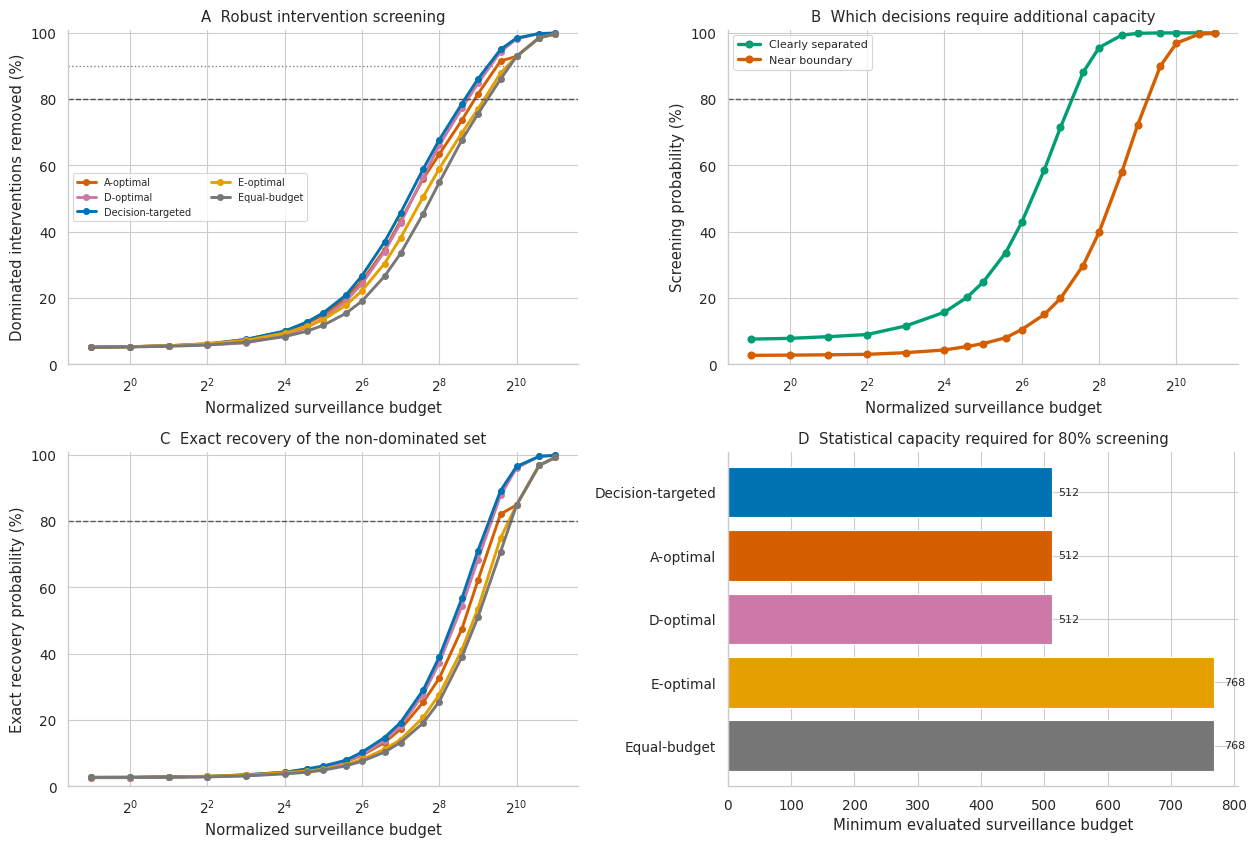

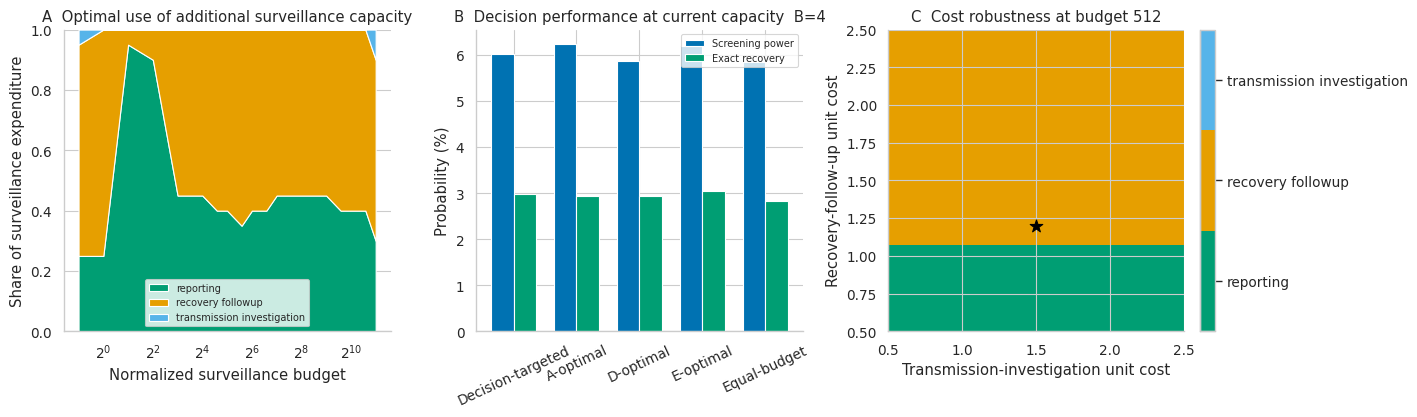


================ CURRENT CAPACITY B=4 ================

           Method  FalseElimination  ScreeningPower  SeparatedPower  NearPower  ExactRecovery
Decision-targeted            0.0002          0.0602          0.0901     0.0303         0.0298
        A-optimal            0.0000          0.0624          0.0947     0.0302         0.0295
        D-optimal            0.0002          0.0588          0.0878     0.0298         0.0293
        E-optimal            0.0000          0.0621          0.0932     0.0310         0.0305
     Equal-budget            0.0000          0.0584          0.0882     0.0287         0.0283

================ CAPACITY TARGETS ====================

           Method  B80Separated  B80Near  B80Overall  B90Overall  B80Exact
Decision-targeted         192.0    768.0       512.0       768.0     768.0
        A-optimal         192.0    768.0       512.0       768.0     768.0
        D-optimal         192.0    768.0       512.0       768.0     768.0
        E-optimal     

In [5]:
# =====================================================================
# CAMEROON MPOX — DIRECT DECISION-TARGETED SURVEILLANCE DESIGN
# ONE GOOGLE COLAB CELL
#
# Fixed main-paper calibration
#   N_eff=175, S0=114, I0=1
#   b=.7650, gamma=.2377, phi=2.4906
#
# Main methodological change
#   DIRECTLY maximizes expected robust screening power
#   subject to false-elimination protection
#
# Comparison
#   Decision-targeted
#   A-optimal
#   D-optimal
#   E-optimal
#   Equal budget
#
# Outputs
#   overall screening power
#   separated-strategy screening
#   near-boundary screening
#   exact non-dominated-set recovery
#   false elimination
#   capacity required for 80/90% performance
#   allocation path
#   cost robustness
#
# Independent optimization/evaluation Monte Carlo samples
# Checkpoints in Google Drive
# =====================================================================

import os,time,pickle,json,warnings
import numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.stats import chi2
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid",context="paper",font_scale=1.12)

from google.colab import drive,files
drive.mount("/content/drive")

# =====================================================================
# SETTINGS
# =====================================================================

ROOT="/content/drive/MyDrive/Cameroon_Direct_Decision_Design"
OUT=f"{ROOT}/results"; CKPT=f"{ROOT}/checkpoint.pkl"
os.makedirs(OUT,exist_ok=True)

# Fixed estimates from main paper
N,S0,I0,R0=175.,114.,1.,60.
BETA,GAMMA,PHI=.7650,.2377,2.4906
ETA=np.log([BETA,GAMMA])

SIGMA0=np.array([
    [.010786,.010329],
    [.010329,.016702]
])
IBASE=np.linalg.inv(SIGMA0)

THRESH=np.array([57,68,80,91,103])

POL={
 "Recovery": (0,.040),
 "Contact":  (.100,0),
 "BalancedA":(.050,.020),
 "BalancedB":(.070,.012),
 "Weak":     (.045,.005),
 "VeryWeak":(.025,.004),
 "Minimal":  (.010,.002)
}
A=list(POL); K=len(A)

# Predefined groups from the main Cameroon analysis
NEAR={"Contact","BalancedA","BalancedB"}
SEPARATED={"Weak","VeryWeak","Minimal"}

# One unit of each surveillance improvement
REPORTING_FRACTION=.25
RECOVERY_OBS=10.
TRANSMISSION_OBS=10.

# Normalized costs
COST={
 "reporting":1.0,
 "recovery_followup":1.2,
 "transmission_investigation":1.5
}

B0=4.

# deliberately broad capacity range
BUDGETS=np.array([
    .5,1,2,4,8,16,24,32,48,64,96,128,
    192,256,384,512,768,1024,1536,2048
])

ALPHA=.05
RADIUS=np.sqrt(chi2.ppf(1-ALPHA,2))

NOPT=800        # optimization sample
NEVAL=6000      # independent evaluation sample

rng1=np.random.default_rng(2027)
rng2=np.random.default_rng(4109)

# common random numbers
ZOPT=rng1.standard_normal((NOPT,2))
ZEVAL=rng2.standard_normal((NEVAL,2))

# =====================================================================
# CHECKPOINT
# =====================================================================

ans=input("R = resume | S = start from beginning: ").strip().lower()
resume=ans.startswith("r") and os.path.exists(CKPT)

if not resume and os.path.exists(CKPT):
    os.remove(CKPT)

state=pickle.load(open(CKPT,"rb")) if resume else {}
last=time.time()

def save(stage,force=False,**kw):
    global state,last
    state.update(kw); state["stage"]=stage
    if force or time.time()-last>=1200:
        pickle.dump(state,open(CKPT,"wb"))
        last=time.time()
        print("checkpoint:",stage)

# =====================================================================
# WEEKLY DATA — automatic, no fitting
# =====================================================================

if "weekly" not in state:

    paths=[
        "/content/Cameroonmpox.csv",
        "/content/drive/MyDrive/Cameroonmpox.csv",
        f"{ROOT}/Cameroonmpox.csv"
    ]

    fn=next((p for p in paths if os.path.exists(p)),None)

    if fn is None:
        print("Upload Cameroonmpox.csv")
        u=files.upload()
        fn="/content/"+next(iter(u))

    d=pd.read_csv(fn)

    dc=next(
        (c for c in d if c.lower()=="date"),
        next(c for c in d if "date" in c.lower())
    )

    d[dc]=pd.to_datetime(d[dc],errors="coerce")
    d=d.dropna(subset=[dc]).sort_values(dc).set_index(dc)
    d=d.loc["2025-11-16":"2026-04-24"]

    if "new_cases" in d:
        x=pd.to_numeric(
            d["new_cases"],errors="coerce"
        ).fillna(0).clip(lower=0)

        weekly=x.resample("W-SUN").sum()

    else:
        cc=next(c for c in d if "total_cases" in c.lower())

        x=pd.to_numeric(
            d[cc],errors="coerce"
        ).ffill()

        z=x.resample("W-SUN").max().ffill()

        weekly=z.diff().fillna(z.iloc[0]).clip(lower=0)

    save("weekly",True,weekly=weekly)

else:
    weekly=state["weekly"]

T=len(weekly)

print(
    f"\nweeks={T} | cases={weekly.sum():.0f} | "
    f"b={BETA} | gamma={GAMMA} | phi={PHI}"
)

weekly.to_csv(f"{OUT}/weekly_incidence.csv")

# =====================================================================
# EXPLICIT SURVEILLANCE INFORMATION
# =====================================================================

def mu_week(eta,H=T):

    b,g=np.exp(eta)

    def rhs(t,z):
        S,I,R=z
        q=b*S*I/N
        return [-q,q-g*I,g*I]

    z=solve_ivp(
        rhs,[0,H],[S0,I0,R0],
        t_eval=np.arange(H+1),
        rtol=1e-9,atol=1e-11
    )

    return np.maximum(
        z.y[0,:-1]-z.y[0,1:],
        1e-10
    )

def Jmu(eta,e=2e-5):

    return np.column_stack([
        (
            mu_week(eta+np.eye(2)[j]*e)
            -mu_week(eta-np.eye(2)[j]*e)
        )/(2*e)

        for j in range(2)
    ])

def reporting_info():

    mu=mu_week(ETA)
    J=Jmu(ETA)

    var=mu+mu**2/PHI

    return J.T@(J/var[:,None])

# Additional independent reporting information
IREP=REPORTING_FRACTION*reporting_info()

# Exponential infectious-duration follow-up
# Fisher information for log(gamma) = 1 per observed duration
IREC=np.diag([0.,RECOVERY_OBS])

# Resolved transmission investigations
# Poisson/exposure interpretation gives information primarily for log(b)
ITRA=np.diag([TRANSMISSION_OBS,0.])

IJ={
 "reporting":IREP,
 "recovery_followup":IREC,
 "transmission_investigation":ITRA
}

SRC=list(IJ)
C=np.array([COST[s] for s in SRC])

print("\nSource information")
for s in SRC:
    print(f"{s:27s} trace={np.trace(IJ[s]):.3f}")

# =====================================================================
# EXACT FINAL-SIZE DISTRIBUTION
# =====================================================================

def final_pmf(b,g,S=int(S0),I=int(I0),N=int(N)):

    X={}

    for s in range(S+1):

        for i in range(N-s+1):

            if i==0 or s==0:
                z=np.zeros(s+1)
                z[0]=1.
                X[s,i]=z
                continue

            p=(b*s/N)/(b*s/N+g)

            r=np.pad(
                X[s,i-1],
                (0,s+1-len(X[s,i-1]))
            )

            nxt=X[s-1,i+1]

            q=np.zeros(s+1)
            q[1:1+len(nxt)]=nxt

            X[s,i]=(1-p)*r+p*q

    return X[S,I]

def risk(eta,a):

    b,g=np.exp(eta)
    db,dg=POL[a]

    p=final_pmf(
        max(b-db,1e-10),
        g+dg
    )

    return np.array([
        p[c+1:].sum()
        if c<len(p)-1 else 0.
        for c in THRESH
    ])

CURVES=np.array([
    risk(ETA,a) for a in A
])

# =====================================================================
# ORACLE DOMINANCE
# =====================================================================

DOM=np.zeros((K,K),bool)

for l in range(K):

    for k in range(K):

        if l!=k:

            DOM[l,k]=(
                np.all(CURVES[l]<=CURVES[k]+1e-12)
                and
                np.any(CURVES[l]<CURVES[k]-1e-12)
            )

oracle_dom=np.array([
    DOM[:,k].any()
    for k in range(K)
])

oracle_nd=np.where(~oracle_dom)[0]

SEP_IDX=np.array([
    i for i,a in enumerate(A)
    if a in SEPARATED and oracle_dom[i]
])

NEAR_IDX=np.array([
    i for i,a in enumerate(A)
    if a in NEAR and oracle_dom[i]
])

print("\nOracle non-dominated =",
      [A[i] for i in oracle_nd])

print("Separated dominated =",
      [A[i] for i in SEP_IDX])

print("Near-boundary dominated =",
      [A[i] for i in NEAR_IDX])

# =====================================================================
# PAIRWISE CONTRASTS
# =====================================================================

def contrast_vector(eta):

    R=[risk(eta,a) for a in A]
    out=[]

    for l in range(K):

        for k in range(K):

            if l!=k:
                out.extend(R[l]-R[k])

    return np.asarray(out)

def jac(fun,x,e=1e-4):

    return np.column_stack([
        (
            fun(x+np.eye(len(x))[j]*e)
            -fun(x-np.eye(len(x))[j]*e)
        )/(2*e)

        for j in range(len(x))
    ])

DEL=contrast_vector(ETA)
G=jac(contrast_vector,ETA)

PAIRS=[]
q=0

for l in range(K):

    for k in range(K):

        if l==k:
            continue

        idx=np.arange(
            q,q+len(THRESH)
        )

        PAIRS.append(
            (l,k,idx)
        )

        q+=len(THRESH)

# =====================================================================
# COVARIANCE AFTER SURVEILLANCE ALLOCATION
# =====================================================================

def Cov(w,IJ_=IJ):

    Q=IBASE.copy()

    for j,s in enumerate(SRC):
        Q+=w[j]*IJ_[s]

    return np.linalg.inv(
        Q+1e-12*np.eye(2)
    )

# =====================================================================
# ROBUST SCREENING METRICS
# Common 95% parameter confidence ellipse
# =====================================================================

def metrics(w,Z,IJ_=IJ):

    S=Cov(w,IJ_)
    L=np.linalg.cholesky(
        S+1e-14*np.eye(2)
    )

    # estimator errors
    E=Z@L.T

    # first-order contrast variance
    v=np.einsum(
        "ij,jk,ik->i",
        G,S,G
    )

    sd=np.sqrt(
        np.maximum(v,1e-15)
    )

    # plug-in contrast over repetitions
    DH=DEL[None,:]+E@G.T

    # common-ellipse upper support bound
    UB=DH+RADIUS*sd[None,:]

    removed=np.zeros(
        (len(Z),K),bool
    )

    for l,k,idx in PAIRS:

        remove=np.all(
            UB[:,idx]<=0,
            axis=1
        )

        removed[:,k]|=remove

    # false removal of true ND alternative
    false=np.mean(
        np.any(
            removed[:,oracle_nd],
            axis=1
        )
    )

    # average dominated screening
    overall=np.mean(
        removed[:,oracle_dom]
    )

    sep=(
        np.mean(removed[:,SEP_IDX])
        if len(SEP_IDX) else np.nan
    )

    near=(
        np.mean(removed[:,NEAR_IDX])
        if len(NEAR_IDX) else np.nan
    )

    # exact oracle set recovery
    retained=~removed

    exact=np.mean([
        np.array_equal(
            np.where(retained[i])[0],
            oracle_nd
        )
        for i in range(len(Z))
    ])

    return {
        "false":false,
        "power":overall,
        "separated":sep,
        "near":near,
        "exact":exact
    }

# =====================================================================
# DIRECT DECISION-TARGETED OPTIMIZATION
#
# The target is exactly the empirical quantity reported in the paper
# maximize expected screening power
# subject to false elimination <= 5%
#
# Optimization sample != evaluation sample
# =====================================================================

def simplex(step):

    n=int(round(1/step))

    return np.array([
        [i/n,j/n,(n-i-j)/n]
        for i in range(n+1)
        for j in range(n-i+1)
    ])

GRID10=simplex(.10)
GRID05=simplex(.05)

def choose(B,c=C,IJ_=IJ,Z=ZOPT,coarse_only=False):

    def evaluate_share(sh):

        # expenditure share -> effort
        w=B*sh/c
        M=metrics(w,Z,IJ_)

        # hard protection constraint
        feasible=M["false"]<=ALPHA+.01

        # lexicographic objective
        # 1 overall screening power
        # 2 near-boundary power
        # 3 exact recovery
        val=(
            M["power"],
            M["near"] if np.isfinite(M["near"]) else -1,
            M["exact"]
        )

        return feasible,val,w,M

    best=None

    # coarse global grid
    for sh in GRID10:

        z=evaluate_share(sh)

        if not z[0]:
            continue

        if best is None or z[1]>best[1]:
            best=(sh,*z[1:])

    if coarse_only or best is None:
        return best[2]

    center=best[0]

    # local refinement on 5% grid
    local=GRID05[
        np.sum(
            np.abs(GRID05-center),
            axis=1
        )<=.30
    ]

    for sh in local:

        z=evaluate_share(sh)

        if not z[0]:
            continue

        if z[1]>best[1]:
            best=(sh,*z[1:])

    return best[2]

# =====================================================================
# CONVENTIONAL OPTIMAL DESIGNS
# =====================================================================

def conventional(B,crit,c=C,IJ_=IJ):

    x0=B/(len(c)*c)

    con={
        "type":"ineq",
        "fun":lambda w:B-c@w
    }

    bd=[
        (0,B/z)
        for z in c
    ]

    if crit=="A":

        f=lambda w:np.trace(
            Cov(w,IJ_)
        )

    elif crit=="D":

        f=lambda w:np.linalg.slogdet(
            Cov(w,IJ_)
        )[1]

    else:

        f=lambda w:np.linalg.eigvalsh(
            Cov(w,IJ_)
        ).max()

    z=minimize(
        f,x0,
        method="SLSQP",
        bounds=bd,
        constraints=con,
        options={
            "maxiter":1200,
            "ftol":1e-12
        }
    )

    return z.x

# =====================================================================
# BUDGET ANALYSIS
# =====================================================================

records=[]

for B in BUDGETS:

    print("Budget",B)

    wd=choose(B)

    W={
        "Decision-targeted":wd,
        "A-optimal":conventional(B,"A"),
        "D-optimal":conventional(B,"D"),
        "E-optimal":conventional(B,"E"),
        "Equal-budget":B/(len(C)*C)
    }

    for name,w in W.items():

        M=metrics(
            w,ZEVAL
        )

        records.append([
            B,name,
            M["false"],
            M["power"],
            M["separated"],
            M["near"],
            M["exact"],
            *w
        ])

    save(
        "budget",
        True,
        budget_results=records
    )

BR=pd.DataFrame(
    records,
    columns=[
        "Budget","Method",
        "FalseElimination",
        "ScreeningPower",
        "SeparatedPower",
        "NearPower",
        "ExactRecovery",
        *SRC
    ]
)

BR.to_csv(
    f"{OUT}/budget_results.csv",
    index=False
)

# =====================================================================
# CAPACITY TARGETS
# =====================================================================

def first_budget(method,col,target):

    z=BR[
        BR.Method==method
    ].sort_values("Budget")

    q=z[z[col]>=target]

    return (
        q.Budget.iloc[0]
        if len(q) else np.nan
    )

CAP=[]

for m in BR.Method.unique():

    CAP.append([
        m,
        first_budget(m,"SeparatedPower",.80),
        first_budget(m,"NearPower",.80),
        first_budget(m,"ScreeningPower",.80),
        first_budget(m,"ScreeningPower",.90),
        first_budget(m,"ExactRecovery",.80)
    ])

CAP=pd.DataFrame(
    CAP,
    columns=[
        "Method",
        "B80Separated",
        "B80Near",
        "B80Overall",
        "B90Overall",
        "B80Exact"
    ]
)

CAP.to_csv(
    f"{OUT}/capacity_targets.csv",
    index=False
)

# =====================================================================
# BASELINE B=4
# =====================================================================

MAIN=BR[
    BR.Budget==B0
].copy()

MAIN.to_csv(
    f"{OUT}/baseline_results.csv",
    index=False
)

# =====================================================================
# ALLOCATION PATH
# =====================================================================

DT=BR[
    BR.Method=="Decision-targeted"
].sort_values("Budget")

shares=[]

for _,r in DT.iterrows():

    effort=np.array([
        r[s] for s in SRC
    ])

    spend=effort*C
    share=spend/spend.sum()

    shares.append(
        [r.Budget,*share]
    )

SH=pd.DataFrame(
    shares,
    columns=[
        "Budget",*SRC
    ]
)

# =====================================================================
# COST ROBUSTNESS
# coarse but direct screening-power optimization
# =====================================================================

b80=CAP.loc[
    CAP.Method=="Decision-targeted",
    "B80Overall"
].iloc[0]

B_HEAT=(
    b80 if np.isfinite(b80)
    else 64.
)

CG=np.linspace(.5,2.5,7)

WIN=np.zeros(
    (len(CG),len(CG)),int
)

for i,cr in enumerate(CG):

    for j,ct in enumerate(CG):

        cc=np.array([
            1.,cr,ct
        ])

        w=choose(
            B_HEAT,
            c=cc,
            Z=ZOPT[:400],
            coarse_only=True
        )

        spend=w*cc
        WIN[i,j]=np.argmax(spend)

# =====================================================================
# FIGURE 1
# =====================================================================

COL={
 "Decision-targeted":"#0072B2",
 "A-optimal":"#D55E00",
 "D-optimal":"#CC79A7",
 "E-optimal":"#E69F00",
 "Equal-budget":"#777777"
}

fig,ax=plt.subplots(
    2,2,
    figsize=(12.7,8.6)
)

# overall power
for m,g in BR.groupby("Method"):

    g=g.sort_values("Budget")

    ax[0,0].plot(
        g.Budget,
        100*g.ScreeningPower,
        "o-",lw=2.1,ms=4,
        color=COL[m],
        label=m
    )

ax[0,0].axhline(
    80,color=".3",
    ls="--",lw=1
)

ax[0,0].axhline(
    90,color=".5",
    ls=":",lw=1
)

ax[0,0].set_xscale(
    "log",base=2
)

ax[0,0].set(
    title="A  Robust intervention screening",
    xlabel="Normalized surveillance budget",
    ylabel="Dominated interventions removed (%)",
    ylim=(0,101)
)

ax[0,0].legend(
    fontsize=7,ncol=2
)

# separated versus near — DT
ax[0,1].plot(
    DT.Budget,
    100*DT.SeparatedPower,
    "o-",lw=2.4,
    label="Clearly separated",
    color="#009E73"
)

ax[0,1].plot(
    DT.Budget,
    100*DT.NearPower,
    "o-",lw=2.4,
    label="Near boundary",
    color="#D55E00"
)

ax[0,1].axhline(
    80,color=".35",
    ls="--",lw=1
)

ax[0,1].set_xscale(
    "log",base=2
)

ax[0,1].set(
    title="B  Which decisions require additional capacity",
    xlabel="Normalized surveillance budget",
    ylabel="Screening probability (%)",
    ylim=(0,101)
)

ax[0,1].legend(fontsize=8)

# exact recovery
for m,g in BR.groupby("Method"):

    ax[1,0].plot(
        g.Budget,
        100*g.ExactRecovery,
        "o-",lw=2.1,ms=4,
        color=COL[m],
        label=m
    )

ax[1,0].axhline(
    80,color=".35",
    ls="--",lw=1
)

ax[1,0].set_xscale(
    "log",base=2
)

ax[1,0].set(
    title="C  Exact recovery of the non-dominated set",
    xlabel="Normalized surveillance budget",
    ylabel="Exact recovery probability (%)",
    ylim=(0,101)
)

# capacity required
cc=CAP.set_index(
    "Method"
).B80Overall.dropna().sort_values()

ax[1,1].barh(
    cc.index,
    cc.values,
    color=[
        COL[x] for x in cc.index
    ]
)

ax[1,1].invert_yaxis()

ax[1,1].set(
    title="D  Statistical capacity required for 80% screening",
    xlabel="Minimum evaluated surveillance budget"
)

for i,v in enumerate(cc):

    ax[1,1].text(
        v*1.02,i,
        f"{v:g}",
        va="center",
        fontsize=8
    )

sns.despine()
plt.tight_layout()

plt.savefig(
    f"{OUT}/decision_performance.png",
    dpi=450,
    bbox_inches="tight"
)

plt.savefig(
    f"{OUT}/decision_performance.pdf",
    bbox_inches="tight"
)

plt.show()

# =====================================================================
# FIGURE 2
# =====================================================================

fig,ax=plt.subplots(
    1,3,
    figsize=(14.3,4.3)
)

# allocation shares
ax[0].stackplot(
    SH.Budget,
    SH[SRC].T.values,
    labels=[
        x.replace("_"," ")
        for x in SRC
    ],
    colors=[
        "#009E73",
        "#E69F00",
        "#56B4E9"
    ]
)

ax[0].set_xscale(
    "log",base=2
)

ax[0].set(
    title="A  Optimal use of additional surveillance capacity",
    xlabel="Normalized surveillance budget",
    ylabel="Share of surveillance expenditure",
    ylim=(0,1)
)

ax[0].legend(
    fontsize=7
)

# fixed B=4
x=np.arange(len(MAIN))
bw=.36

ax[1].bar(
    x-bw/2,
    100*MAIN.ScreeningPower,
    bw,
    color="#0072B2",
    label="Screening power"
)

ax[1].bar(
    x+bw/2,
    100*MAIN.ExactRecovery,
    bw,
    color="#009E73",
    label="Exact recovery"
)

ax[1].set_xticks(
    x,
    MAIN.Method,
    rotation=25
)

ax[1].set(
    title=f"B  Decision performance at current capacity  B={B0:g}",
    ylabel="Probability (%)"
)

ax[1].legend(
    fontsize=7
)

# cost heatmap
cmap=plt.matplotlib.colors.ListedColormap([
    "#009E73",
    "#E69F00",
    "#56B4E9"
])

im=ax[2].imshow(
    WIN,
    origin="lower",
    aspect="auto",
    extent=[
        CG.min(),CG.max(),
        CG.min(),CG.max()
    ],
    cmap=cmap,
    vmin=-.5,
    vmax=2.5
)

ax[2].scatter(
    COST["transmission_investigation"],
    COST["recovery_followup"],
    marker="*",s=90,c="black"
)

ax[2].set(
    title=f"C  Cost robustness at budget {B_HEAT:g}",
    xlabel="Transmission-investigation unit cost",
    ylabel="Recovery-follow-up unit cost"
)

cb=fig.colorbar(
    im,ax=ax[2],
    ticks=[0,1,2],
    fraction=.046
)

cb.ax.set_yticklabels([
    x.replace("_"," ")
    for x in SRC
])

sns.despine()
plt.tight_layout()

plt.savefig(
    f"{OUT}/allocation_capacity.png",
    dpi=450,
    bbox_inches="tight"
)

plt.savefig(
    f"{OUT}/allocation_capacity.pdf",
    bbox_inches="tight"
)

plt.show()

# =====================================================================
# REPORT
# =====================================================================

print("\n================ CURRENT CAPACITY B=4 ================\n")
print(
    MAIN[
        [
            "Method",
            "FalseElimination",
            "ScreeningPower",
            "SeparatedPower",
            "NearPower",
            "ExactRecovery"
        ]
    ].round(4).to_string(index=False)
)

print("\n================ CAPACITY TARGETS ====================\n")
print(
    CAP.to_string(index=False)
)

print("\n================ KEY CAPACITY RESULT =================")

C80=CAP.set_index(
    "Method"
).B80Overall

bd=C80.get(
    "Decision-targeted",
    np.nan
)

if np.isfinite(bd):

    print(
        f"\nDecision-targeted design reaches "
        f"80% screening at budget {bd:g}."
    )

    for m in [
        "Equal-budget",
        "A-optimal",
        "D-optimal",
        "E-optimal"
    ]:

        bm=C80.get(m,np.nan)

        if np.isfinite(bm):

            saving=100*(
                bm-bd
            )/bm

            print(
                f"{m:13s} requires {bm:g}. "
                f"Capacity saving = {saving:.1f}%."
            )

        else:

            print(
                f"{m:13s} does not reach 80% "
                f"within the evaluated range."
            )

# Save summary
summary={
    "fixed_parameters":{
        "N_eff":N,
        "b":BETA,
        "gamma":GAMMA,
        "phi":PHI
    },
    "oracle_non_dominated":[
        A[i] for i in oracle_nd
    ],
    "capacity_targets":
        CAP.to_dict("records"),
    "baseline":
        MAIN.to_dict("records")
}

json.dump(
    summary,
    open(
        f"{OUT}/summary.json",
        "w"
    ),
    indent=2
)

save(
    "done",
    True,
    summary=summary
)

print("\nDONE")
print("Results saved in")
print(OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
R = resume | S = start from beginning: S
checkpoint: weekly

Weeks=24 | cases=49 | N_eff=175 | b=0.765 | gamma=0.2377 | phi=2.4906

Incremental information per surveillance unit
reporting                   trace=78.8794
recovery_followup           trace=10.0000
transmission_investigation  trace=10.0000

Oracle non-dominated = ['Recovery']
Separated dominated = ['Weak', 'VeryWeak', 'Minimal']
Near-boundary dominated = ['Contact', 'BalancedA', 'BalancedB']

Continuous capacity search
Decision-targeted
checkpoint: capacity
A-optimal
checkpoint: capacity
D-optimal
checkpoint: capacity
E-optimal
checkpoint: capacity
Equal-budget
checkpoint: capacity


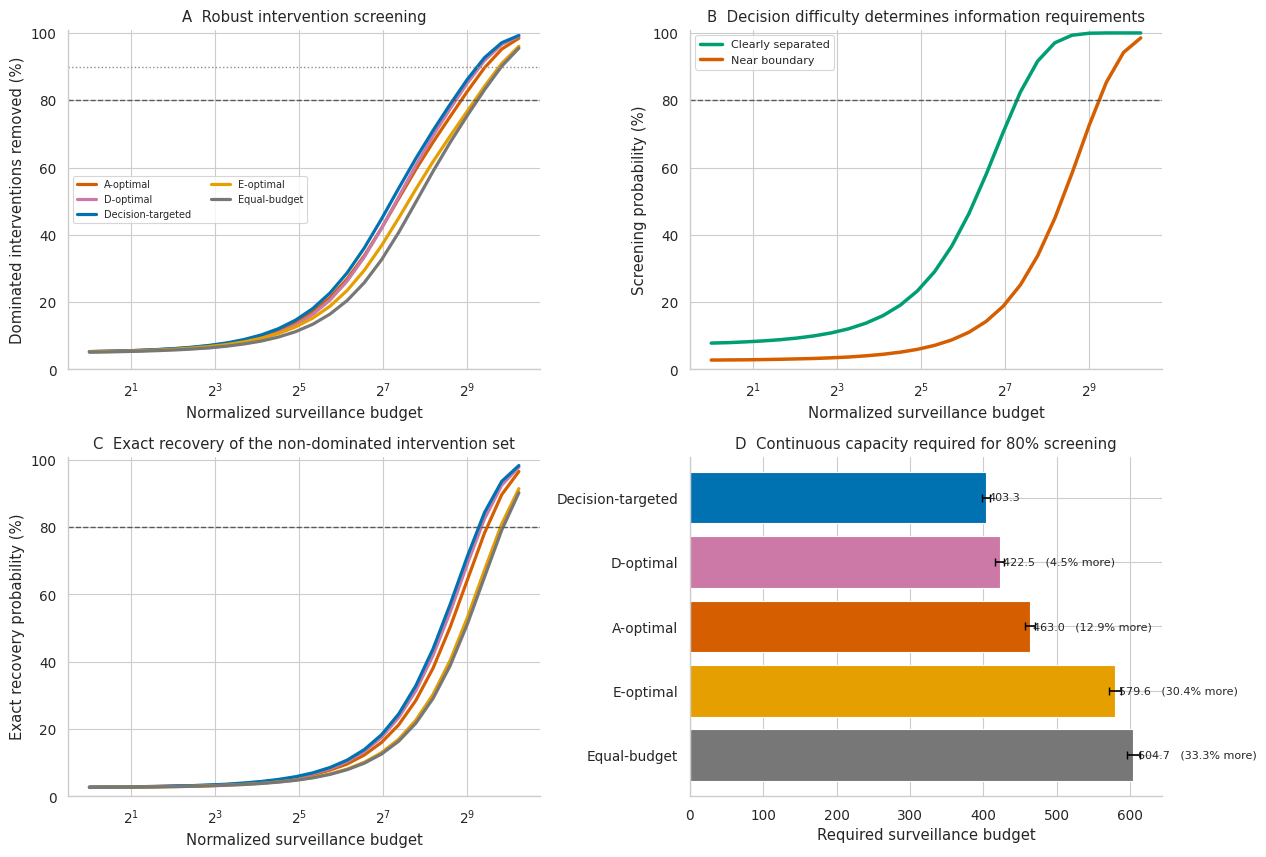

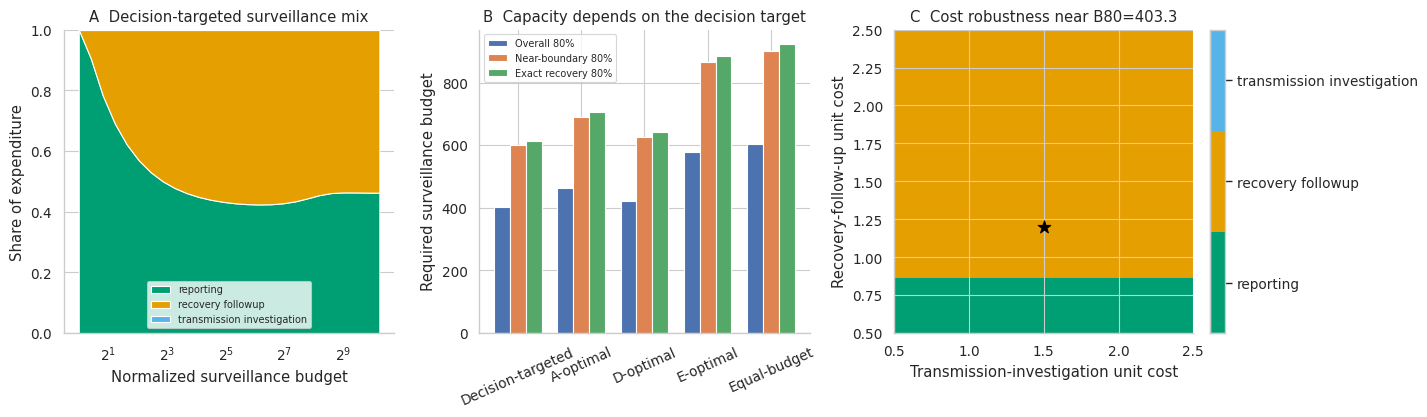


================ CONTINUOUS CAPACITY TARGETS ================

           Method  B80Overall  B90Overall  B80Separated  B80Near  B80Exact
Decision-targeted      403.34      599.88        154.82   599.64    614.84
        A-optimal      463.01      690.17        165.93   689.94    706.08
        D-optimal      422.55      626.87        170.91   626.42    642.61
        E-optimal      579.63      865.74        196.94   865.61    884.58
     Equal-budget      604.65      899.73        234.67   899.37    922.74

================ CAPACITY SAVINGS ============================

  Comparator  DT_B80  Comparator_B80  CapacitySavingPct
   A-optimal  403.34          463.01              12.89
   D-optimal  403.34          422.55               4.54
   E-optimal  403.34          579.63              30.41
Equal-budget  403.34          604.65              33.29

================ INDEPENDENT VALIDATION ======================

           Method     Target   Budget  Performance  CI_low  CI_high
Decision

In [7]:
# ======================================================================
# CAMEROON MPOX — CONTINUOUS DECISION-TARGETED CAPACITY DESIGN
# ONE GOOGLE COLAB CELL
#
# Main-paper calibration
# N_eff=175, S0=114, I0=1, R0=60
# b=.7650, gamma=.2377, phi=2.4906
#
# Improvements over previous version
# 1. Continuous capacity thresholds rather than coarse {256,512,768,...}
# 2. Decision-targeted design optimizes a smooth screening-probability target
# 3. Independent Sobol quasi-Monte Carlo validation
# 4. Continuous B80 overall, B90 overall, B80 near-boundary, B80 exact
# 5. Capacity savings relative to A/D/E/equal allocation
# 6. Monte Carlo uncertainty bands for performance curves
# 7. Publication-quality figures
# 8. Google Drive checkpoint every 20 minutes
# ======================================================================

import os,time,pickle,json,warnings
import numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.stats import chi2,norm,qmc
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid",context="paper",font_scale=1.12)

from google.colab import drive,files
drive.mount("/content/drive")

# ======================================================================
# SETTINGS
# ======================================================================

ROOT="/content/drive/MyDrive/Cameroon_Continuous_Decision_Design"
OUT=f"{ROOT}/results"; CKPT=f"{ROOT}/checkpoint.pkl"
os.makedirs(OUT,exist_ok=True)

# ----- fixed values from original paper -----
N,S0,I0,R0=175.,114.,1.,60.
BETA,GAMMA,PHI=.7650,.2377,2.4906
ETA=np.log([BETA,GAMMA])

SIGMA0=np.array([
    [.010786,.010329],
    [.010329,.016702]
])
IBASE=np.linalg.inv(SIGMA0)

THRESH=np.array([57,68,80,91,103])

POL={
 "Recovery": (0,.040),
 "Contact":  (.100,0),
 "BalancedA":(.050,.020),
 "BalancedB":(.070,.012),
 "Weak":     (.045,.005),
 "VeryWeak":(.025,.004),
 "Minimal":  (.010,.002)
}
A=list(POL); K=len(A)

# classification from main Cameroon analysis
NEAR={"Contact","BalancedA","BalancedB"}
SEPARATED={"Weak","VeryWeak","Minimal"}

# explicit surveillance units
REPORTING_FRACTION=.25
RECOVERY_OBS=10.
TRANSMISSION_OBS=10.

COST={
 "reporting":1.0,
 "recovery_followup":1.2,
 "transmission_investigation":1.5
}

COSTV=np.array(list(COST.values()))
ALPHA=.05
RADIUS=np.sqrt(chi2.ppf(1-ALPHA,2))

# Continuous capacity search
BMIN=.25
BMAX=4096.
BASELINE_B=4.

# deterministic QMC samples
NQMC=2**14

# ======================================================================
# CHECKPOINT
# ======================================================================

ans=input("R = resume | S = start from beginning: ").strip().lower()
resume=ans.startswith("r") and os.path.exists(CKPT)

if not resume and os.path.exists(CKPT):
    os.remove(CKPT)

state=pickle.load(open(CKPT,"rb")) if resume else {}
last_save=time.time()

def save(stage,force=False,**kw):
    global state,last_save
    state.update(kw); state["stage"]=stage
    if force or time.time()-last_save>=1200:
        pickle.dump(state,open(CKPT,"wb"))
        last_save=time.time()
        print("checkpoint:",stage)

# ======================================================================
# WEEKLY DATA — automatic, no refitting
# ======================================================================

if "weekly" not in state:

    paths=[
        "/content/Cameroonmpox.csv",
        "/content/drive/MyDrive/Cameroonmpox.csv",
        f"{ROOT}/Cameroonmpox.csv"
    ]

    fn=next((p for p in paths if os.path.exists(p)),None)

    if fn is None:
        print("Upload Cameroonmpox.csv")
        u=files.upload()
        fn="/content/"+next(iter(u))

    d=pd.read_csv(fn)

    dc=next(
        (c for c in d if c.lower()=="date"),
        next(c for c in d if "date" in c.lower())
    )

    d[dc]=pd.to_datetime(d[dc],errors="coerce")
    d=d.dropna(subset=[dc]).sort_values(dc).set_index(dc)
    d=d.loc["2025-11-16":"2026-04-24"]

    if "new_cases" in d:

        x=pd.to_numeric(
            d["new_cases"],errors="coerce"
        ).fillna(0).clip(lower=0)

        weekly=x.resample("W-SUN").sum()

    else:

        cc=next(c for c in d if "total_cases" in c.lower())

        x=pd.to_numeric(
            d[cc],errors="coerce"
        ).ffill()

        z=x.resample("W-SUN").max().ffill()

        weekly=z.diff().fillna(z.iloc[0]).clip(lower=0)

    save("weekly",True,weekly=weekly)

else:
    weekly=state["weekly"]

T=len(weekly)

print(
    f"\nWeeks={T} | cases={weekly.sum():.0f} | "
    f"N_eff={N:.0f} | b={BETA} | gamma={GAMMA} | phi={PHI}"
)

weekly.to_csv(f"{OUT}/weekly_incidence.csv")

# ======================================================================
# EXPLICIT SURVEILLANCE INFORMATION
# ======================================================================

def mu_week(eta,H=T):

    b,g=np.exp(eta)

    def rhs(t,z):

        S,I,R=z
        q=b*S*I/N

        return [-q,q-g*I,g*I]

    z=solve_ivp(
        rhs,[0,H],[S0,I0,R0],
        t_eval=np.arange(H+1),
        rtol=1e-9,atol=1e-11
    )

    return np.maximum(
        z.y[0,:-1]-z.y[0,1:],
        1e-10
    )

def Jmu(eta,e=2e-5):

    return np.column_stack([
        (
            mu_week(eta+np.eye(2)[j]*e)
            -mu_week(eta-np.eye(2)[j]*e)
        )/(2*e)

        for j in range(2)
    ])

def reporting_info():

    mu=mu_week(ETA)
    J=Jmu(ETA)

    var=mu+mu**2/PHI

    return J.T@(J/var[:,None])

IREP=REPORTING_FRACTION*reporting_info()
IREC=np.diag([0.,RECOVERY_OBS])
ITRA=np.diag([TRANSMISSION_OBS,0.])

IJ={
 "reporting":IREP,
 "recovery_followup":IREC,
 "transmission_investigation":ITRA
}

SRC=list(IJ)

print("\nIncremental information per surveillance unit")

for s in SRC:
    print(f"{s:27s} trace={np.trace(IJ[s]):.4f}")

# ======================================================================
# EXACT FINITE POPULATION FINAL SIZE
# ======================================================================

def final_pmf(b,g,S=int(S0),I=int(I0),N=int(N)):

    X={}

    for s in range(S+1):

        for i in range(N-s+1):

            if i==0 or s==0:

                z=np.zeros(s+1)
                z[0]=1.
                X[s,i]=z
                continue

            p=(b*s/N)/(b*s/N+g)

            rec=np.pad(
                X[s,i-1],
                (0,s+1-len(X[s,i-1]))
            )

            nxt=X[s-1,i+1]

            inf=np.zeros(s+1)
            inf[1:1+len(nxt)]=nxt

            X[s,i]=(1-p)*rec+p*inf

    return X[S,I]

def risk(eta,a):

    b,g=np.exp(eta)
    db,dg=POL[a]

    p=final_pmf(
        max(b-db,1e-10),
        g+dg
    )

    return np.array([
        p[c+1:].sum()
        if c<len(p)-1 else 0.
        for c in THRESH
    ])

CURVES=np.array([
    risk(ETA,a)
    for a in A
])

# ======================================================================
# ORACLE DOMINANCE
# ======================================================================

DOM=np.zeros((K,K),bool)

for l in range(K):

    for k in range(K):

        if l==k:
            continue

        DOM[l,k]=(
            np.all(CURVES[l]<=CURVES[k]+1e-12)
            and
            np.any(CURVES[l]<CURVES[k]-1e-12)
        )

oracle_dom=np.array([
    DOM[:,k].any()
    for k in range(K)
])

oracle_nd=np.where(~oracle_dom)[0]

SEP_IDX=np.array([
    i for i,a in enumerate(A)
    if a in SEPARATED and oracle_dom[i]
])

NEAR_IDX=np.array([
    i for i,a in enumerate(A)
    if a in NEAR and oracle_dom[i]
])

print("\nOracle non-dominated =",[A[i] for i in oracle_nd])
print("Separated dominated =",[A[i] for i in SEP_IDX])
print("Near-boundary dominated =",[A[i] for i in NEAR_IDX])

# ======================================================================
# CONTRASTS + SENSITIVITIES
# ======================================================================

def contrasts(eta):

    R=[
        risk(eta,a)
        for a in A
    ]

    out=[]

    for l in range(K):

        for k in range(K):

            if l!=k:
                out.extend(
                    R[l]-R[k]
                )

    return np.asarray(out)

def jac(fun,x,e=1e-4):

    return np.column_stack([
        (
            fun(x+np.eye(len(x))[j]*e)
            -fun(x-np.eye(len(x))[j]*e)
        )/(2*e)

        for j in range(len(x))
    ])

DEL=contrasts(ETA)
G=jac(contrasts,ETA)

PAIRS=[]
q=0

for l in range(K):

    for k in range(K):

        if l==k:
            continue

        idx=np.arange(
            q,q+len(THRESH)
        )

        PAIRS.append(
            (l,k,idx)
        )

        q+=len(THRESH)

# ======================================================================
# COVARIANCE
# ======================================================================

def Cov(w,IJ_=IJ):

    Q=IBASE.copy()

    for j,s in enumerate(SRC):
        Q+=w[j]*IJ_[s]

    return np.linalg.inv(
        Q+1e-12*np.eye(2)
    )

# ======================================================================
# SMOOTH DECISION-TARGETED OBJECTIVE
#
# For each truly dominated intervention estimate how likely at least one
# true dominator is to establish simultaneous dominance.
# ======================================================================

def screening_surrogate(w,IJ_=IJ):

    S=Cov(w,IJ_)
    out=[]

    for k in np.where(oracle_dom)[0]:

        candidate=[]

        for l in np.where(DOM[:,k])[0]:

            idx=next(
                z for a,b,z in PAIRS
                if a==l and b==k
            )

            margin=-DEL[idx]
            GG=G[idx]

            var=np.einsum(
                "ij,jk,ik->i",
                GG,S,GG
            )

            se=np.sqrt(
                np.maximum(var,1e-15)
            )

            # bottleneck threshold for this pair
            z=np.min(
                margin/se-RADIUS
            )

            candidate.append(
                norm.cdf(z)
            )

        out.append(
            max(candidate)
        )

    return np.mean(out)

# ======================================================================
# OPTIMIZATION
# ======================================================================

def effort_from_share(sh,B,c=COSTV):

    sh=np.maximum(sh,0)
    sh=sh/sh.sum()

    return B*sh/c

def optimize_design(B,method,c=COSTV,IJ_=IJ):

    cons={
        "type":"eq",
        "fun":lambda x:x.sum()-1
    }

    bounds=[(0,1)]*3

    starts=[
        [1/3,1/3,1/3],
        [.90,.05,.05],
        [.05,.90,.05],
        [.05,.05,.90],
        [.60,.35,.05],
        [.40,.55,.05],
        [.50,.45,.05],
        [.70,.25,.05],
        [.35,.60,.05]
    ]

    best=None

    for x0 in starts:

        if method=="Decision-targeted":

            f=lambda sh:-screening_surrogate(
                effort_from_share(sh,B,c),IJ_
            )

        elif method=="A-optimal":

            f=lambda sh:np.trace(
                Cov(
                    effort_from_share(sh,B,c),
                    IJ_
                )
            )

        elif method=="D-optimal":

            f=lambda sh:np.linalg.slogdet(
                Cov(
                    effort_from_share(sh,B,c),
                    IJ_
                )
            )[1]

        else:

            f=lambda sh:np.linalg.eigvalsh(
                Cov(
                    effort_from_share(sh,B,c),
                    IJ_
                )
            ).max()

        z=minimize(
            f,
            np.asarray(x0,float),
            method="SLSQP",
            bounds=bounds,
            constraints=cons,
            options={
                "maxiter":1500,
                "ftol":1e-13
            }
        )

        if z.success and (
            best is None
            or z.fun<best.fun
        ):
            best=z

    if best is None:
        sh=np.ones(3)/3
    else:
        sh=np.clip(best.x,0,None)
        sh/=sh.sum()

    return effort_from_share(
        sh,B,c
    )

# ======================================================================
# SOBOL QUASI MONTE CARLO
# ======================================================================

sob=qmc.Sobol(
    d=2,
    scramble=True,
    seed=2027
)

U=sob.random_base2(
    int(np.log2(NQMC))
)

U=np.clip(
    U,1e-10,1-1e-10
)

Z=norm.ppf(U)

# second independent Sobol sample
sob2=qmc.Sobol(
    d=2,
    scramble=True,
    seed=9927
)

U2=sob2.random_base2(
    int(np.log2(NQMC))
)

Z2=norm.ppf(
    np.clip(U2,1e-10,1-1e-10)
)

# ======================================================================
# SCREENING PERFORMANCE
# ======================================================================

def performance(w,Zs=Z,IJ_=IJ):

    S=Cov(w,IJ_)

    L=np.linalg.cholesky(
        S+1e-14*np.eye(2)
    )

    E=Zs@L.T

    var=np.einsum(
        "ij,jk,ik->i",
        G,S,G
    )

    sd=np.sqrt(
        np.maximum(var,1e-15)
    )

    DH=DEL[None,:]+E@G.T
    UB=DH+RADIUS*sd[None,:]

    removed=np.zeros(
        (len(Zs),K),bool
    )

    for l,k,idx in PAIRS:

        removed[:,k]|=np.all(
            UB[:,idx]<=0,
            axis=1
        )

    false_r=np.any(
        removed[:,oracle_nd],
        axis=1
    ).astype(float)

    overall_r=removed[
        :,oracle_dom
    ].mean(axis=1)

    sep_r=(
        removed[:,SEP_IDX].mean(axis=1)
        if len(SEP_IDX)
        else np.repeat(np.nan,len(Zs))
    )

    near_r=(
        removed[:,NEAR_IDX].mean(axis=1)
        if len(NEAR_IDX)
        else np.repeat(np.nan,len(Zs))
    )

    retained=~removed

    exact_r=np.array([
        np.array_equal(
            np.where(retained[i])[0],
            oracle_nd
        )
        for i in range(len(Zs))
    ],float)

    def Sstat(x):

        x=np.asarray(x,float)
        x=x[np.isfinite(x)]

        m=x.mean()
        se=x.std(ddof=1)/np.sqrt(len(x))

        return (
            m,
            max(0,m-1.96*se),
            min(1,m+1.96*se)
        )

    return {
        "false":Sstat(false_r),
        "overall":Sstat(overall_r),
        "separated":Sstat(sep_r),
        "near":Sstat(near_r),
        "exact":Sstat(exact_r)
    }

METHODS=[
    "Decision-targeted",
    "A-optimal",
    "D-optimal",
    "E-optimal",
    "Equal-budget"
]

CACHE={}

def evaluate(method,B,Zs=Z):

    key=(
        method,
        round(float(B),5),
        id(Zs)
    )

    if key in CACHE:
        return CACHE[key]

    if method=="Equal-budget":

        w=B/(3*COSTV)

    else:

        w=optimize_design(
            B,method
        )

    P=performance(
        w,Zs
    )

    CACHE[key]=(w,P)

    return w,P

# ======================================================================
# CONTINUOUS MINIMUM CAPACITY
# ======================================================================

def get_metric(method,B,metric,idx=0):

    _,P=evaluate(
        method,B,Z
    )

    return P[metric][idx]

def capacity(
    method,
    metric,
    target,
    idx=0
):

    lo=BMIN
    hi=1.

    while (
        get_metric(
            method,hi,
            metric,idx
        ) < target
    ):

        lo=hi
        hi*=1.5

        if hi>BMAX:
            return np.nan

    # geometric bisection
    for _ in range(18):

        mid=np.sqrt(
            lo*hi
        )

        if (
            get_metric(
                method,mid,
                metric,idx
            ) >= target
        ):

            hi=mid

        else:

            lo=mid

    return hi

TARGETS={
    "B80Overall":("overall",.80),
    "B90Overall":("overall",.90),
    "B80Near":("near",.80),
    "B90Near":("near",.90),
    "B80Exact":("exact",.80),
    "B80Separated":("separated",.80)
}

CAP=[]

print("\nContinuous capacity search")

for method in METHODS:

    row={"Method":method}

    print(method)

    for name,(metric,target) in TARGETS.items():

        row[name]=capacity(
            method,
            metric,
            target,
            0
        )

        # approximate QMC uncertainty interval
        row[name+"_low"]=capacity(
            method,
            metric,
            target,
            2
        )

        row[name+"_high"]=capacity(
            method,
            metric,
            target,
            1
        )

    CAP.append(row)

    save(
        "capacity",
        True,
        capacity=CAP
    )

CAP=pd.DataFrame(CAP)

CAP.to_csv(
    f"{OUT}/continuous_capacity.csv",
    index=False
)

# ======================================================================
# INDEPENDENT VALIDATION OF B80
# ======================================================================

VAL=[]

for _,r in CAP.iterrows():

    method=r.Method

    for target_name in [
        "B80Overall",
        "B90Overall",
        "B80Near",
        "B80Exact"
    ]:

        B=r[target_name]

        if not np.isfinite(B):
            continue

        if method=="Equal-budget":
            w=B/(3*COSTV)
        else:
            w=optimize_design(
                B,method
            )

        P=performance(
            w,Z2
        )

        metric={
            "B80Overall":"overall",
            "B90Overall":"overall",
            "B80Near":"near",
            "B80Exact":"exact"
        }[target_name]

        VAL.append([
            method,
            target_name,
            B,
            *P[metric],
            *w
        ])

VAL=pd.DataFrame(
    VAL,
    columns=[
        "Method",
        "Target",
        "Budget",
        "Performance",
        "CI_low",
        "CI_high",
        *SRC
    ]
)

VAL.to_csv(
    f"{OUT}/independent_validation.csv",
    index=False
)

# ======================================================================
# PERFORMANCE CURVES
# ======================================================================

mx=np.nanmax(
    CAP[
        [
            "B80Overall",
            "B90Overall",
            "B80Near",
            "B80Exact"
        ]
    ].values
)

mx=(
    2048
    if not np.isfinite(mx)
    else min(BMAX,mx*1.3)
)

PLOT_B=np.geomspace(
    1,
    mx,
    26
)

CUR=[]

for B in PLOT_B:

    for method in METHODS:

        w,P=evaluate(
            method,B,Z
        )

        CUR.append([
            B,
            method,
            *P["overall"],
            *P["near"],
            *P["separated"],
            *P["exact"],
            *w
        ])

CUR=pd.DataFrame(
    CUR,
    columns=[
        "Budget","Method",
        "Overall","OverallLo","OverallHi",
        "Near","NearLo","NearHi",
        "Separated","SeparatedLo","SeparatedHi",
        "Exact","ExactLo","ExactHi",
        *SRC
    ]
)

CUR.to_csv(
    f"{OUT}/performance_curves.csv",
    index=False
)

# ======================================================================
# CURRENT CAPACITY
# ======================================================================

BASE=[]

for method in METHODS:

    w,P=evaluate(
        method,
        BASELINE_B,
        Z2
    )

    BASE.append([
        method,
        *w,
        P["false"][0],
        P["overall"][0],
        P["separated"][0],
        P["near"][0],
        P["exact"][0]
    ])

BASE=pd.DataFrame(
    BASE,
    columns=[
        "Method",*SRC,
        "FalseElimination",
        "ScreeningPower",
        "SeparatedPower",
        "NearPower",
        "ExactRecovery"
    ]
)

BASE.to_csv(
    f"{OUT}/baseline_results.csv",
    index=False
)

# ======================================================================
# DT ALLOCATION PATH
# ======================================================================

AP=[]

for B in PLOT_B:

    w,_=evaluate(
        "Decision-targeted",
        B,Z
    )

    spend=w*COSTV
    share=spend/spend.sum()

    AP.append([
        B,*share
    ])

AP=pd.DataFrame(
    AP,
    columns=[
        "Budget",*SRC
    ]
)

# ======================================================================
# COST ROBUSTNESS
# ======================================================================

BDT=CAP.loc[
    CAP.Method=="Decision-targeted",
    "B80Overall"
].iloc[0]

if not np.isfinite(BDT):
    BDT=512.

CG=np.linspace(
    .5,2.5,11
)

WIN=np.zeros(
    (len(CG),len(CG)),
    int
)

for i,cr in enumerate(CG):

    for j,ct in enumerate(CG):

        c=np.array([
            1.,cr,ct
        ])

        w=optimize_design(
            BDT,
            "Decision-targeted",
            c=c
        )

        spend=w*c

        WIN[i,j]=np.argmax(
            spend
        )

# ======================================================================
# CAPACITY SAVINGS TABLE
# ======================================================================

ZC=CAP.set_index("Method")
bd=ZC.loc[
    "Decision-targeted",
    "B80Overall"
]

SAV=[]

for m in [
    "A-optimal",
    "D-optimal",
    "E-optimal",
    "Equal-budget"
]:

    bm=ZC.loc[
        m,
        "B80Overall"
    ]

    saving=(
        100*(bm-bd)/bm
        if np.isfinite(bm)
        and np.isfinite(bd)
        else np.nan
    )

    SAV.append([
        m,bd,bm,saving
    ])

SAV=pd.DataFrame(
    SAV,
    columns=[
        "Comparator",
        "DT_B80",
        "Comparator_B80",
        "CapacitySavingPct"
    ]
)

SAV.to_csv(
    f"{OUT}/capacity_savings.csv",
    index=False
)

# ======================================================================
# FIGURE 1
# ======================================================================

COL={
 "Decision-targeted":"#0072B2",
 "A-optimal":"#D55E00",
 "D-optimal":"#CC79A7",
 "E-optimal":"#E69F00",
 "Equal-budget":"#777777"
}

fig,ax=plt.subplots(
    2,2,
    figsize=(12.8,8.7)
)

# ---- A overall screening ----
for m,g in CUR.groupby("Method"):

    ax[0,0].plot(
        g.Budget,
        100*g.Overall,
        lw=2.3,
        color=COL[m],
        label=m
    )

ax[0,0].axhline(
    80,color=".35",
    ls="--",lw=1
)

ax[0,0].axhline(
    90,color=".55",
    ls=":",lw=1
)

ax[0,0].set_xscale(
    "log",base=2
)

ax[0,0].set(
    title="A  Robust intervention screening",
    xlabel="Normalized surveillance budget",
    ylabel="Dominated interventions removed (%)",
    ylim=(0,101)
)

ax[0,0].legend(
    fontsize=7,
    ncol=2
)

# ---- B near versus separated ----
d=CUR[
    CUR.Method=="Decision-targeted"
]

ax[0,1].plot(
    d.Budget,
    100*d.Separated,
    lw=2.5,
    color="#009E73",
    label="Clearly separated"
)

ax[0,1].plot(
    d.Budget,
    100*d.Near,
    lw=2.5,
    color="#D55E00",
    label="Near boundary"
)

ax[0,1].axhline(
    80,color=".35",
    ls="--",lw=1
)

ax[0,1].set_xscale(
    "log",base=2
)

ax[0,1].set(
    title="B  Decision difficulty determines information requirements",
    xlabel="Normalized surveillance budget",
    ylabel="Screening probability (%)",
    ylim=(0,101)
)

ax[0,1].legend(fontsize=8)

# ---- C exact recovery ----
for m,g in CUR.groupby("Method"):

    ax[1,0].plot(
        g.Budget,
        100*g.Exact,
        lw=2.3,
        color=COL[m]
    )

ax[1,0].axhline(
    80,color=".35",
    ls="--",lw=1
)

ax[1,0].set_xscale(
    "log",base=2
)

ax[1,0].set(
    title="C  Exact recovery of the non-dominated intervention set",
    xlabel="Normalized surveillance budget",
    ylabel="Exact recovery probability (%)",
    ylim=(0,101)
)

# ---- D continuous B80 ----
vals=ZC.B80Overall.sort_values()

ax[1,1].barh(
    vals.index,
    vals.values,
    color=[
        COL[x]
        for x in vals.index
    ]
)

ax[1,1].invert_yaxis()

for i,(m,v) in enumerate(vals.items()):

    lo=ZC.loc[
        m,
        "B80Overall_low"
    ]

    hi=ZC.loc[
        m,
        "B80Overall_high"
    ]

    if np.isfinite(lo) and np.isfinite(hi):

        ax[1,1].errorbar(
            v,i,
            xerr=[
                [max(0,v-lo)],
                [max(0,hi-v)]
            ],
            color="black",
            capsize=3,
            fmt="none"
        )

    saving=(
        100*(v-bd)/v
        if m!="Decision-targeted"
        and np.isfinite(v)
        else 0
    )

    label=(
        f"{v:.1f}"
        if m=="Decision-targeted"
        else f"{v:.1f}   ({saving:.1f}% more)"
    )

    ax[1,1].text(
        v*1.01,
        i,
        label,
        va="center",
        fontsize=8
    )

ax[1,1].set(
    title="D  Continuous capacity required for 80% screening",
    xlabel="Required surveillance budget"
)

sns.despine()
plt.tight_layout()

plt.savefig(
    f"{OUT}/continuous_decision_results.png",
    dpi=450,
    bbox_inches="tight"
)

plt.savefig(
    f"{OUT}/continuous_decision_results.pdf",
    bbox_inches="tight"
)

plt.show()

# ======================================================================
# FIGURE 2
# ======================================================================

fig,ax=plt.subplots(
    1,3,
    figsize=(14.4,4.3)
)

# allocation path
ax[0].stackplot(
    AP.Budget,
    AP[SRC].T.values,
    labels=[
        s.replace("_"," ")
        for s in SRC
    ],
    colors=[
        "#009E73",
        "#E69F00",
        "#56B4E9"
    ]
)

ax[0].set_xscale(
    "log",base=2
)

ax[0].set(
    title="A  Decision-targeted surveillance mix",
    xlabel="Normalized surveillance budget",
    ylabel="Share of expenditure",
    ylim=(0,1)
)

ax[0].legend(
    fontsize=7
)

# capacity targets
targets=pd.DataFrame({
    "Overall 80%":
        ZC.B80Overall,
    "Near-boundary 80%":
        ZC.B80Near,
    "Exact recovery 80%":
        ZC.B80Exact
})

x=np.arange(
    len(targets)
)

bw=.25

for j,col in enumerate(
    targets.columns
):

    ax[1].bar(
        x+(j-1)*bw,
        targets[col],
        bw,
        label=col
    )

ax[1].set_xticks(
    x,
    targets.index,
    rotation=24
)

ax[1].set(
    title="B  Capacity depends on the decision target",
    ylabel="Required surveillance budget"
)

ax[1].legend(
    fontsize=7
)

# cost robustness
cmap=plt.matplotlib.colors.ListedColormap([
    "#009E73",
    "#E69F00",
    "#56B4E9"
])

im=ax[2].imshow(
    WIN,
    origin="lower",
    aspect="auto",
    extent=[
        CG.min(),CG.max(),
        CG.min(),CG.max()
    ],
    cmap=cmap,
    vmin=-.5,
    vmax=2.5
)

ax[2].scatter(
    COST["transmission_investigation"],
    COST["recovery_followup"],
    marker="*",
    s=90,
    c="black"
)

ax[2].set(
    title=f"C  Cost robustness near B80={BDT:.1f}",
    xlabel="Transmission-investigation unit cost",
    ylabel="Recovery-follow-up unit cost"
)

cb=fig.colorbar(
    im,
    ax=ax[2],
    ticks=[0,1,2],
    fraction=.046
)

cb.ax.set_yticklabels([
    s.replace("_"," ")
    for s in SRC
])

sns.despine()
plt.tight_layout()

plt.savefig(
    f"{OUT}/allocation_and_targets.png",
    dpi=450,
    bbox_inches="tight"
)

plt.savefig(
    f"{OUT}/allocation_and_targets.pdf",
    bbox_inches="tight"
)

plt.show()

# ======================================================================
# REPORT
# ======================================================================

print("\n================ CONTINUOUS CAPACITY TARGETS ================\n")

print(
    CAP[
        [
            "Method",
            "B80Overall",
            "B90Overall",
            "B80Separated",
            "B80Near",
            "B80Exact"
        ]
    ].round(2).to_string(index=False)
)

print("\n================ CAPACITY SAVINGS ============================\n")

print(
    SAV.round(2).to_string(index=False)
)

print("\n================ INDEPENDENT VALIDATION ======================\n")

print(
    VAL[
        [
            "Method",
            "Target",
            "Budget",
            "Performance",
            "CI_low",
            "CI_high"
        ]
    ].round(4).to_string(index=False)
)

print("\n================ CURRENT CAPACITY B=4 ========================\n")

print(
    BASE[
        [
            "Method",
            "FalseElimination",
            "ScreeningPower",
            "SeparatedPower",
            "NearPower",
            "ExactRecovery"
        ]
    ].round(4).to_string(index=False)
)

# ======================================================================
# KEY RESULT
# ======================================================================

print("\n================ KEY RESULT =================================")

print(
    f"Decision-targeted B80 = {bd:.2f}"
)

for _,r in SAV.iterrows():

    print(
        f"{r.Comparator:13s} "
        f"B80={r.Comparator_B80:.2f}   "
        f"DT capacity saving={r.CapacitySavingPct:.1f}%"
    )

bn=ZC.loc[
    "Decision-targeted",
    "B80Near"
]

bs=ZC.loc[
    "Decision-targeted",
    "B80Separated"
]

if np.isfinite(bn) and np.isfinite(bs):

    print(
        f"\nNear-boundary decisions require "
        f"{bn/bs:.2f}x the capacity of clearly separated decisions."
    )

summary={
    "fixed_model":{
        "N_eff":N,
        "S0":S0,
        "I0":I0,
        "b":BETA,
        "gamma":GAMMA,
        "phi":PHI
    },
    "capacity":
        CAP.to_dict("records"),
    "savings":
        SAV.to_dict("records"),
    "validation":
        VAL.to_dict("records"),
    "baseline":
        BASE.to_dict("records")
}

json.dump(
    summary,
    open(
        f"{OUT}/summary.json",
        "w"
    ),
    indent=2
)

save(
    "done",
    True,
    summary=summary
)

print("\nDONE")
print(OUT)